In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

df = df.iloc[:, :2]
df.columns = ['label', 'text']

print(df.shape)
df.head()

(5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

df = df.drop_duplicates()

df.columns = ['label', 'text'] if len(df.columns) == 2 else df.columns

df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df = df.dropna()

print(df['label'].value_counts())

label    0
text     0
dtype: int64
403
label
0    4516
1     653
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2224\2656671512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


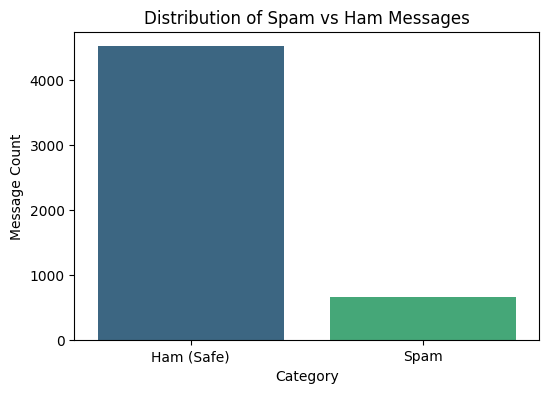

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='viridis')
plt.xticks([0, 1], ['Ham (Safe)', 'Spam'])
plt.xlabel('Category')
plt.ylabel('Message Count')
plt.title('Distribution of Spam vs Ham Messages')
plt.show()

In [6]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [7]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9671179883945842
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.98      0.78      0.87       145

    accuracy                           0.97      1034
   macro avg       0.97      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [8]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9671179883945842
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.98      0.78      0.87       145

    accuracy                           0.97      1034
   macro avg       0.97      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [9]:
joblib.dump(model, 'spam_model.joblib')
joblib.dump(vectorizer, 'vectorizer.joblib')
print("Model and Vectorizer files saved successfully.")

Model and Vectorizer files saved successfully.


In [10]:
loaded_model = joblib.load('spam_model.joblib')
loaded_vec = joblib.load('vectorizer.joblib')

raw_texts = [
    "Hey, are we still meeting for lunch today at 1 PM?",
    "URGENT! You have won a 1-week free cruise to the Bahamas! Call 090512 to claim now!"
]

cleaned_inputs = loaded_vec.transform(raw_texts)
predictions = loaded_model.predict(cleaned_inputs)
probabilities = loaded_model.predict_proba(cleaned_inputs)[:, 1]

for text, pred, prob in zip(raw_texts, predictions, probabilities):
    label_name = "SPAM" if pred == 1 else "HAM (SAFE)"
    print(f"Message: '{text}' -> Detection: {label_name} (Spam Prob: {prob*100:.2f}%)")

Message: 'Hey, are we still meeting for lunch today at 1 PM?' -> Detection: HAM (SAFE) (Spam Prob: 3.39%)
Message: 'URGENT! You have won a 1-week free cruise to the Bahamas! Call 090512 to claim now!' -> Detection: SPAM (Spam Prob: 78.73%)
